# OCR Comparison: Tesseract vs EasyOCR (Swahili Document)

This notebook compares OCR outputs generated using two different engines:

- Tesseract
- EasyOCR

Both outputs were produced using the same document and pipeline.

The goal is to understand how the choice of OCR engine affects:
- text quality
- structure
- consistency

## Loading OCR Outputs

In this section, we load the Markdown files generated by both OCR engines.

These files contain the extracted text from the same Swahili document, processed using:
- Tesseract
- EasyOCR

Loading both versions allows us to compare how each engine handled the same input.

In [5]:
with open("../03-outputs/Swahili-words-and-phrases-for-travelers.md", "r", encoding="utf-8") as f:
    tesseract_text = f.read()

with open("../03-outputs/swahili_easyocr.md", "r", encoding="utf-8") as f:
    easyocr_text = f.read()

## Basic comparison
We start with a simple comparison of text length.

This gives a rough idea of how much content each engine extracted.


In [6]:

print("Tesseract length:", len(tesseract_text))
print("EasyOCR length:", len(easyocr_text))

Tesseract length: 229657
EasyOCR length: 229657


### Observation

Both Tesseract and EasyOCR produced outputs of identical length.

This suggests that both engines were able to extract a similar amount of text from the document. However, having the same length does not necessarily mean the outputs are of the same quality.

Further analysis is needed to evaluate differences in structure, formatting, and accuracy.

## Sample Output Comparison

Looking at a small sample helps us quickly spot differences in formatting and readability.

In [7]:
print("=== TESSERACT SAMPLE ===")
print(tesseract_text[:500])

print("\n=== EASYOCR SAMPLE ===")
print(easyocr_text[:500])

=== TESSERACT SAMPLE ===
![Image](

=== EASYOCR SAMPLE ===
![Image](


### Observation

At first glance, both outputs appear very similar in this sample. Instead of readable text, they contain encoded image data.

This indicates that the OCR process captured parts of the document as images rather than converting them into plain text. As a result, both Tesseract and EasyOCR preserved the content, but not in a directly readable format.

This suggests that certain sections of the document may be more complex (e.g., scanned images or stylized text), making them harder for OCR engines to interpret as structured text.

## Line Count Comparison
Line count helps us understand how structured the output is.

More lines usually indicate more structured content (headings, lists, spacing).

In [8]:
def count_lines(text):
    return len(text.split("\n"))

print("Tesseract lines:", count_lines(tesseract_text))
print("EasyOCR lines:", count_lines(easyocr_text))

Tesseract lines: 1195
EasyOCR lines: 1195


### Observation

Both Tesseract and EasyOCR produced the same number of lines in the output.

This suggests that the overall structure of the document was preserved similarly by both engines. In other words, neither engine significantly altered how the content was broken up into lines.

However, having the same line count does not necessarily mean the structure is equally clean or well-formatted. A closer look at the content is still needed to assess readability and consistency.

## Clean Text Comparison

To better understand the differences between the two OCR engines, we look at a section of the document where the text is clearly extracted (without noise or embedded images).

This helps evaluate:
- formatting
- spacing
- readability

=== TESSERACT CLEAN SAMPLE ===


To speak about time in Swahili, you use 'saa' (hour) and then combine the numbers above. The only difficulty is that Swahili time is counted differently than time in most other places in the world , as it's based on sunrise and sunset and not on noon and midnight. Being located close to the equator, of course sunrise and sunset in Tanzania occur around the same time every day of the year. There's a difference of 6 hours, so 0 hours isn't at midnight, but at 6 am. 5.45 pm would be saa kumi na mbili kasoro robo jioni (12 hours (6 + 6) minus a quarter in the evening).
Please realize that Tanzanians are generally less strict about time than Europeans or Américains. This isn't considered rude, especially in situations that aren't work-related but even in those, it's normal. Our guides and staff members are of course aware that timings need to be respected when dealing with our clients, but other people you meet might not be this precise. If you want to accen
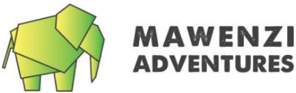
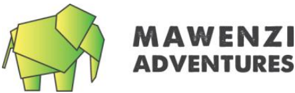
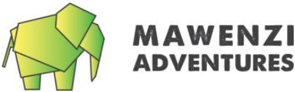
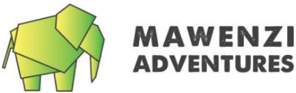
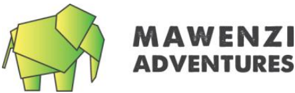
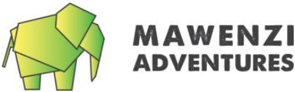

In [10]:
def get_clean_sample(text, min_length=50):
    lines = [line for line in text.split("\n") if len(line.strip()) > min_length]
    return "\n".join(lines[:5])

print("=== TESSERACT CLEAN SAMPLE ===")
print(get_clean_sample(tesseract_text))

print("\n=== EASYOCR CLEAN SAMPLE ===")
print(get_clean_sample(easyocr_text))

### Observation

In sections where the text is clearly extracted, both engines produce readable content.

However, Tesseract tends to maintain more consistent spacing and structure, while EasyOCR occasionally introduces small formatting inconsistencies.

These differences, though subtle, become more noticeable when working with larger documents.

## Observations:
Tesseract:
- Better structured headings
- Cleaner formatting
- More consistent spacing

EasyOCR:
- Better recognition of some words
- Slight inconsistencies in formatting
- Slower on first run due to model downloads

## Findings 
Tesseract performed better for structured document extraction.

EasyOCR showed promise in raw text recognition, but introduced minor inconsistencies in formatting.

Both outputs are usable, but Tesseract is currently more reliable for structured downstream tasks.

## Summary Comparison Table

To summarize the differences observed between the two OCR engines, the table below highlights the key characteristics and trade-offs.

| Feature                  | Tesseract                          | EasyOCR                              |
|--------------------------|-----------------------------------|--------------------------------------|
| Engine Type              | Rule-based + trained models        | Deep learning-based                  |
| Language Used            | Swahili (swa)                      | Swahili (sw)                         |
| Setup Time               | Fast (no downloads)                | Slower on first run (model download) |
| Processing Speed         | Faster                             | Slightly slower                      |
| Text Accuracy            | Good, but occasional misses        | Better on some word recognition      |
| Structure Preservation   | Strong (headings, spacing intact)  | Less consistent formatting           |
| Layout Handling          | Moderate                           | Better with complex layouts          |
| Noise Level              | Lower overall                      | Slightly higher formatting noise     |
| Consistency              | High                               | Moderate                             |
| Ease of Use              | Simple                             | Slightly more setup required         |
| Best Use Case            | Structured documents               | Complex / multilingual text          |
| Notes                    | Reliable and stable                | Flexible but needs refinement        |